In [4]:
import polars as pl
import matplotlib
import numpy as np
import math
import pyarrow as pa
import IProgress
import hashlib
import io
from PIL import Image
from pathlib import Path
import plotly.express as px
import nbformat

In [5]:
print(pl.__version__)
print(pa.__version__)

1.40.0
23.0.1


In [6]:
# Import dataset
splits = {'train': 'data/train-00000-of-00001.parquet', 'validation': 'data/validation-00000-of-00001.parquet', 'test': 'data/test-00000-of-00001.parquet'}
df_train = pl.read_parquet('hf://datasets/mmenendezg/pneumonia_x_ray/' + splits['train'])
df_test = pl.read_parquet('hf://datasets/mmenendezg/pneumonia_x_ray/' + splits['test'])
df_val = pl.read_parquet('hf://datasets/mmenendezg/pneumonia_x_ray/' + splits['validation'])

The original splits contained overlapping images (based on hashed bytes). By concatenating the three splits and removing duplicate images, I can resplit the data without leakage.

In [7]:
df = pl.concat([df_train, df_test, df_val])

#### First look

In [8]:
df.head

<bound method DataFrame.head of shape: (5_856, 2)
┌─────────────────────────────────┬───────┐
│ image                           ┆ label │
│ ---                             ┆ ---   │
│ struct[2]                       ┆ i64   │
╞═════════════════════════════════╪═══════╡
│ {b"\xff\xd8\xff\xe0\x00\x10JFI… ┆ 0     │
│ {b"\xff\xd8\xff\xe0\x00\x10JFI… ┆ 0     │
│ {b"\xff\xd8\xff\xe0\x00\x10JFI… ┆ 0     │
│ {b"\xff\xd8\xff\xe0\x00\x10JFI… ┆ 0     │
│ {b"\xff\xd8\xff\xe0\x00\x10JFI… ┆ 0     │
│ …                               ┆ …     │
│ {b"\xff\xd8\xff\xe0\x00\x10JFI… ┆ 1     │
│ {b"\xff\xd8\xff\xe0\x00\x10JFI… ┆ 1     │
│ {b"\xff\xd8\xff\xe0\x00\x10JFI… ┆ 1     │
│ {b"\xff\xd8\xff\xe0\x00\x10JFI… ┆ 1     │
│ {b"\xff\xd8\xff\xe0\x00\x10JFI… ┆ 1     │
└─────────────────────────────────┴───────┘>

In [9]:
df.schema

Schema([('image', Struct({'bytes': Binary, 'path': String})),
        ('label', Int64)])

In [10]:
df.group_by("label").len()

label,len
i64,u32
1,4273
0,1583


### Check for duplicates

In [11]:
total_rows = df.height
unique_paths = df.select(pl.col("image").struct.field("path").n_unique()).item()
unique_hashes = df.select(pl.col("image").struct.field("bytes").hash().n_unique()).item()

print("Total rows:", total_rows)
print("Unique paths:", unique_paths)
print("Unique hashes:", unique_hashes)

Total rows: 5856
Unique paths: 4273
Unique hashes: 5383


It seems like a decent number of images use the same path, but only a few of the images are actually identical.

In [12]:
# Add image_hash and image_path columns
df = df.with_columns(pl.col("image").struct.field("bytes").hash().alias("image_hash"))
df = df.with_columns(pl.col("image").struct.field("path").alias("image_path"))
df.head(5)

image,label,image_hash,image_path
struct[2],i64,u64,str
"{b""\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00C\x00\x08\x06\x06\x07\x06\x05\x08\x07\x07\x07\x09\x09\x08\x0a\x0c\x14\x0d\x0c\x0b\x0b\x0c\x19\x12\x13\x0f\x14\x1d\x1a\x1f\x1e\x1d\x1a\x1c\x1c\x20""…,""train-0.jpeg""}",0,15624522136123532950,"""train-0.jpeg"""
"{b""\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00C\x00\x08\x06\x06\x07\x06\x05\x08\x07\x07\x07\x09\x09\x08\x0a\x0c\x14\x0d\x0c\x0b\x0b\x0c\x19\x12\x13\x0f\x14\x1d\x1a\x1f\x1e\x1d\x1a\x1c\x1c\x20""…,""train-1.jpeg""}",0,18221970835360844062,"""train-1.jpeg"""
"{b""\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00C\x00\x08\x06\x06\x07\x06\x05\x08\x07\x07\x07\x09\x09\x08\x0a\x0c\x14\x0d\x0c\x0b\x0b\x0c\x19\x12\x13\x0f\x14\x1d\x1a\x1f\x1e\x1d\x1a\x1c\x1c\x20""…,""train-10.jpeg""}",0,9990647761240806942,"""train-10.jpeg"""
"{b""\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00C\x00\x08\x06\x06\x07\x06\x05\x08\x07\x07\x07\x09\x09\x08\x0a\x0c\x14\x0d\x0c\x0b\x0b\x0c\x19\x12\x13\x0f\x14\x1d\x1a\x1f\x1e\x1d\x1a\x1c\x1c\x20""…,""train-100.jpeg""}",0,10330418483954177345,"""train-100.jpeg"""
"{b""\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00C\x00\x08\x06\x06\x07\x06\x05\x08\x07\x07\x07\x09\x09\x08\x0a\x0c\x14\x0d\x0c\x0b\x0b\x0c\x19\x12\x13\x0f\x14\x1d\x1a\x1f\x1e\x1d\x1a\x1c\x1c\x20""…,""train-1000.jpeg""}",0,13266960183753597657,"""train-1000.jpeg"""


In [13]:
exact_dupes = df.filter(
    pl.struct(["image_hash", "label", "image_path"]).is_duplicated()
)
len(exact_dupes)

0

In [14]:
hash_dupes = df.filter(pl.struct(["image_hash"]).is_duplicated())
len(hash_dupes)

937

In [15]:
# Find out if any duplicate hashes have different labels
dup_hashes = (
    df.group_by("image_hash")
    .agg([
        pl.col("image_path").n_unique().alias("unique_paths"),
        pl.col("label").n_unique().alias("unique_labels")
    ])
    .filter(pl.col("unique_paths") > 1)
)

print("Duplicate hashes:", len(dup_hashes))


Duplicate hashes: 464


In [16]:
dup_hashes.sort(pl.col("unique_labels"), descending=True)

image_hash,unique_paths,unique_labels
u64,u32,u32
17178489390230692853,2,1
18068287191877136842,2,1
14633458145485872888,2,1
17484523729844576660,2,1
4519434413357934706,2,1
…,…,…
17206302227964361276,2,1
13534360207336383570,2,1
2987237453780915152,2,1


It appears that duplicate image hashes all have identical labels, just unique paths. Because there is not overlap, it is safe to drop the duplicates.

In [17]:
# Drop the duplicates
df = df.unique(subset='image_hash')

In [18]:
print("Rows after removing duplicates: ", df.height)
print(df.group_by("label").len())

Rows after removing duplicates:  5383
shape: (2, 2)
┌───────┬──────┐
│ label ┆ len  │
│ ---   ┆ ---  │
│ i64   ┆ u32  │
╞═══════╪══════╡
│ 1     ┆ 3916 │
│ 0     ┆ 1467 │
└───────┴──────┘


### Saving images, renaming files to hashes

In [19]:
# New folder for images
out_dir = Path("data/clean_xrays")
out_dir.mkdir(parents=True, exist_ok=True)

In [20]:
# Shuffle the data
df = df.sample(fraction=1, seed=12)

In [21]:
df.schema

Schema([('image', Struct({'bytes': Binary, 'path': String})),
        ('label', Int64),
        ('image_hash', UInt64),
        ('image_path', String)])

In [22]:
def save_image(image_struct, image_hash):
    """
    Save an image from raw bytes to disk using a hash-based filename.
    Returns file path to the image
    """
    image_bytes = image_struct['bytes']
    out_path = (out_dir / f"{image_hash}.png")

    if not out_path.exists():
        img = Image.open(io.BytesIO(image_bytes))
        img.save(out_path)
    return out_path.as_posix()


In [23]:
df = df.with_columns(
    pl.struct(["image", "image_hash"])
    .map_elements(
        lambda row: save_image(row["image"], row["image_hash"]),
        return_dtype=pl.String
    )
    .alias("file_path")
)

In [24]:
df = df.select(['file_path', 'image_hash', 'label'])

In [25]:
df.head

<bound method DataFrame.head of shape: (5_383, 3)
┌─────────────────────────────────┬──────────────────────┬───────┐
│ file_path                       ┆ image_hash           ┆ label │
│ ---                             ┆ ---                  ┆ ---   │
│ str                             ┆ u64                  ┆ i64   │
╞═════════════════════════════════╪══════════════════════╪═══════╡
│ data/clean_xrays/4524897631946… ┆ 4524897631946214135  ┆ 1     │
│ data/clean_xrays/3669981055164… ┆ 3669981055164393421  ┆ 1     │
│ data/clean_xrays/8275583105524… ┆ 8275583105524660605  ┆ 1     │
│ data/clean_xrays/4188275775369… ┆ 4188275775369942459  ┆ 1     │
│ data/clean_xrays/7355192060493… ┆ 7355192060493769753  ┆ 1     │
│ …                               ┆ …                    ┆ …     │
│ data/clean_xrays/1256814465616… ┆ 12568144656164332225 ┆ 1     │
│ data/clean_xrays/8052344773400… ┆ 8052344773400179870  ┆ 1     │
│ data/clean_xrays/4008741750683… ┆ 4008741750683621708  ┆ 0     │
│ data/clean

### Train/Test/val split

In [26]:
n = df.height

In [27]:
train_end = int(0.7*n)
val_end = int(0.9*n)

In [28]:
train_df = df[:train_end]
val_df = df[train_end:val_end]
test_df = df[val_end:]

In [29]:
train_counts = (
    train_df.group_by("label")
    .len()
    .with_columns(
        (pl.col("len") / train_df.height).alias("proportion")
    )
)
fig = px.pie(
    train_counts,
    names="label",
    values="proportion",
    title="Train Split Class Distribution"
)
fig.show()

In [30]:
test_counts = (
    test_df.group_by("label")
    .len()
    .with_columns(
        (pl.col("len") / test_df.height).alias("proportion")
    )
)
fig = px.pie(
    test_counts,
    names="label",
    values="proportion",
    title="Test Split Class Distribution"
)
fig.show()

In [31]:
val_counts = (
    val_df.group_by("label")
    .len()
    .with_columns(
        (pl.col("len") / val_df.height).alias("proportion")
    )
)
fig = px.pie(
    val_counts,
    names="label",
    values="proportion",
    title="Validation Split Class Distribution"
)
fig.show()

In [32]:
train_hashes = set(train_df["image_hash"])
val_hashes = set(val_df["image_hash"])
test_hashes = set(test_df["image_hash"])

In [33]:
print("train-val overlap:", len(train_hashes & val_hashes))
print("train-test overlap:", len(train_hashes & test_hashes))
print("val-test overlap:", len(val_hashes & test_hashes))

train-val overlap: 0
train-test overlap: 0
val-test overlap: 0


In [34]:
# label train/val images, concat into one df for fastai
train_df = train_df.with_columns(val = False)
val_df = val_df.with_columns(val = True)
df = pl.concat(
    [
        train_df,
        val_df,
    ],
    how="vertical"
)
df.head

<bound method DataFrame.head of shape: (4_844, 4)
┌─────────────────────────────────┬──────────────────────┬───────┬───────┐
│ file_path                       ┆ image_hash           ┆ label ┆ val   │
│ ---                             ┆ ---                  ┆ ---   ┆ ---   │
│ str                             ┆ u64                  ┆ i64   ┆ bool  │
╞═════════════════════════════════╪══════════════════════╪═══════╪═══════╡
│ data/clean_xrays/4524897631946… ┆ 4524897631946214135  ┆ 1     ┆ false │
│ data/clean_xrays/3669981055164… ┆ 3669981055164393421  ┆ 1     ┆ false │
│ data/clean_xrays/8275583105524… ┆ 8275583105524660605  ┆ 1     ┆ false │
│ data/clean_xrays/4188275775369… ┆ 4188275775369942459  ┆ 1     ┆ false │
│ data/clean_xrays/7355192060493… ┆ 7355192060493769753  ┆ 1     ┆ false │
│ …                               ┆ …                    ┆ …     ┆ …     │
│ data/clean_xrays/2116057723395… ┆ 2116057723395002682  ┆ 1     ┆ true  │
│ data/clean_xrays/1276562057965… ┆ 12765620579655

In [35]:
from PIL import Image
img = Image.open(df['file_path'][0])
print(img.size)
print(img.mode)

(500, 500)
RGB


In [36]:
df_pandas = df.to_pandas()

In [37]:
df_pandas.head()

,file_path,image_hash,label,val
0,data/clean_xrays/4524897631946214135.png,4524897631946214135,1,False
1,data/clean_xrays/3669981055164393421.png,3669981055164393421,1,False
2,data/clean_xrays/8275583105524660605.png,8275583105524660605,1,False
3,data/clean_xrays/4188275775369942459.png,4188275775369942459,1,False
4,data/clean_xrays/7355192060493769753.png,7355192060493769753,1,False


### Fastai/modeling

In [38]:
from fastai.vision.all import *
import torch
import fastai

In [39]:
dls = ImageDataLoaders.from_df(
    df_pandas,
    path='.',
    fn_col='file_path',
    label_col='label',
    valid_col='val',
    item_tfms=Resize(224),
    batch_tfms=[*aug_transforms(
        do_flip=False,
        flip_vert=False,
        max_rotate=20,
        max_zoom=1.2,
        max_warp=0.2,
        max_lighting=0.2,
        ),
        Normalize.from_stats(*imagenet_stats)
    ]
)

Transforms loosely based on the parameters provided in table 3 of "Pneumonia Detection from Chest X-Ray Images Using Deep Learning and Transfer Learning for Imbalanced Datasets", found here: https://pmc.ncbi.nlm.nih.gov/articles/PMC12344030/#Sec22

In [40]:
model_path = Path('pneumonia_learner.pkl')

if model_path.exists():
    learn = load_learner(model_path)
else:
    learn = vision_learner(
        dls,
        resnet34,
        metrics=[accuracy, Precision(), Recall(), F1Score()]
    )
    learn.fine_tune(5)
    learn.export(model_path)

c:\Users\chris\PycharmProjects\Chest_xrays\.venv\Lib\site-packages\fastai\learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


In [41]:
print(type(learn.loss_func))
print(learn.dls)
print(learn.dls.valid)

<class 'fastai.losses.CrossEntropyLossFlat'>


In [42]:
x,y = dls.one_batch()

In [43]:
y

TensorCategory([1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
                1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1,
                0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1,
                1], device='cuda:0')

In [44]:
preds,targs = learn.get_preds(dl=[(x,y)])

In [45]:
learn = vision_learner(dls, resnet34, metrics=error_rate)
learn.fine_tune(1, base_lr=0.1)

epoch,train_loss,valid_loss,error_rate,time
0,0.653565,3.524191,0.314126,00:26


epoch,train_loss,valid_loss,error_rate,time
0,0.404076,0.542390,0.103160,00:28


<div></div>

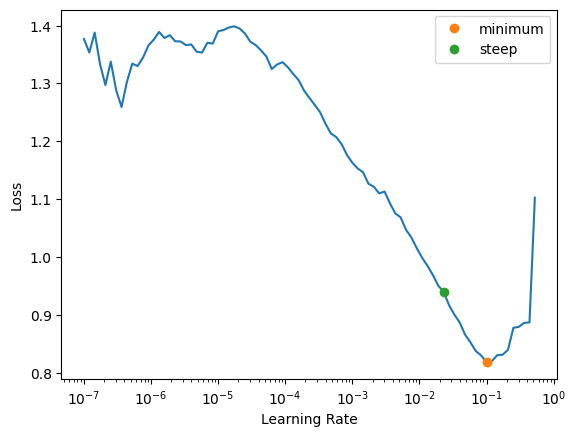

In [46]:
learn = vision_learner(dls, resnet34, metrics=error_rate)
lr_min,lr_steep = learn.lr_find(suggest_funcs=(minimum, steep))

In [47]:
print(f"{lr_min:.2e}, {lr_steep:.2e}")

1.00e-02, 2.29e-02


In [48]:
learn = vision_learner(dls, resnet34, metrics=[accuracy, Precision(), Recall(), F1Score()])
learn.fine_tune(2, base_lr=1e-3)

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.664572,0.525913,0.849442,0.981162,0.806452,0.885269,00:27


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.324762,0.319137,0.917286,0.985836,0.898065,0.939905,00:28
1,0.221488,0.214612,0.936803,0.984911,0.926452,0.954787,00:29


In [49]:
learn.fine_tune??

Signature:
learn.fine_tune(
    epochs,
    base_lr=0.002,
    freeze_epochs=1,
    lr_mult=100,
    pct_start=0.3,
    div=5.0,
    *,
    lr_max=None,
    div_final=100000.0,
    wd=None,
    moms=None,
    cbs=None,
    reset_opt=False,
    start_epoch=0,
)
Source:   
@patch
@delegates(Learner.fit_one_cycle)
def fine_tune(self:Learner, epochs, base_lr=2e-3, freeze_epochs=1, lr_mult=100,
              pct_start=0.3, div=5.0, **kwargs):
    "Fine tune with `Learner.freeze` for `freeze_epochs`, then with `Learner.unfreeze` for `epochs`, using discriminative LR."
    self.freeze()
    self.fit_one_cycle(freeze_epochs, slice(base_lr), pct_start=0.99, **kwargs)
    base_lr /= 2
    self.unfreeze()
    self.fit_one_cycle(epochs, slice(base_lr/lr_mult, base_lr), pct_start=pct_start, div=div, **kwargs)
File:      c:\users\chris\pycharmprojects\chest_xrays\.venv\lib\site-packages\fastai\callback\schedule.py
Type:      method

In [50]:
learn=vision_learner(dls, resnet34, metrics=[accuracy, Precision(), Recall(), F1Score()])
learn.fit_one_cycle(3, 1e-3)

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.566248,0.309743,0.917286,0.975069,0.908387,0.940548,00:28
1,0.331021,0.252269,0.938662,0.987620,0.926452,0.956059,00:27
2,0.250517,0.223590,0.945167,0.989071,0.934194,0.960849,00:28


In [51]:
learn.unfreeze()

<div></div>

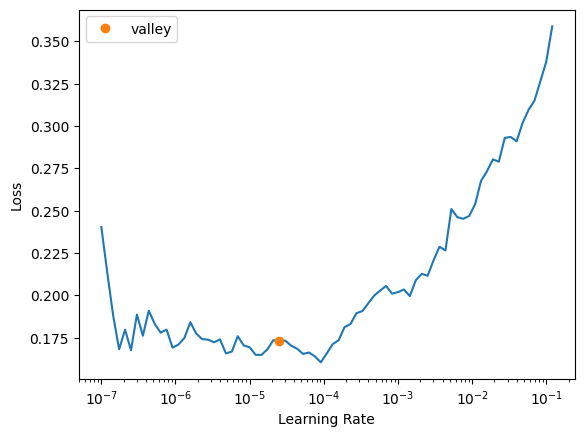

In [52]:
lr_valley = learn.lr_find(suggest_funcs=(valley,))

In [53]:
lr_valley

SuggestedLRs(valley=2.511886486900039e-05)

In [54]:
learn.fit_one_cycle(5, lr_max=slice(6.30957365501672e-05/100, 6.30957365501672e-05))

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.210822,0.246613,0.939591,0.990331,0.925161,0.956638,00:29
1,0.187843,0.224068,0.952602,0.990515,0.943226,0.966292,00:29
2,0.170335,0.162112,0.958178,0.989276,0.952258,0.970414,00:29
3,0.160697,0.218089,0.953532,0.990528,0.944516,0.966975,00:29
4,0.149944,0.188566,0.956320,0.990566,0.948387,0.969018,00:30


<Axes: title={'center': 'learning curve'}, xlabel='steps', ylabel='loss'>

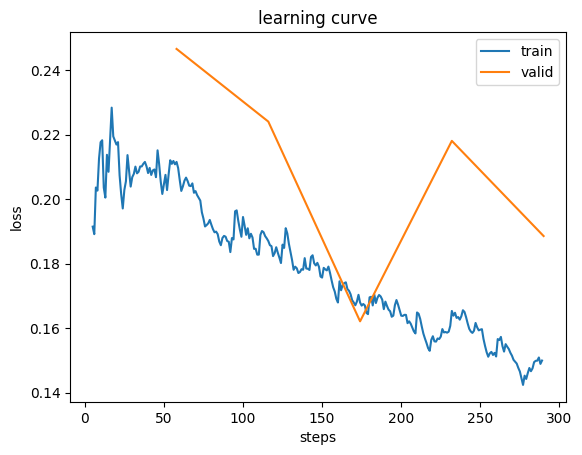

In [55]:
learn.recorder.plot_loss()

In [56]:
from fastai.callback.fp16 import *

In [57]:
learn = vision_learner(dls, resnet50, metrics=[accuracy, Precision(), Recall(), F1Score()]).to_fp16()
learn.fine_tune(6, freeze_epochs=3)

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.673556,0.292331,0.882900,0.903106,0.938065,0.920253,00:28
1,0.478416,0.524482,0.863383,0.981595,0.825806,0.896987,00:29
2,0.348175,0.274534,0.909851,0.960598,0.912258,0.935804,00:30


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.227786,0.274414,0.925651,0.979310,0.916129,0.946667,00:30
1,0.204489,0.179294,0.934015,0.957143,0.950968,0.954045,00:30
2,0.162299,0.219676,0.934015,0.983516,0.923871,0.952761,00:31
3,0.126070,0.186811,0.937732,0.988950,0.923871,0.955304,00:31
4,0.112212,0.147854,0.954461,0.982713,0.953548,0.967911,00:30
5,0.095765,0.171323,0.946097,0.986431,0.938065,0.961640,00:30


In [58]:
from fastai.metrics import RocAuc
from sklearn.metrics import recall_score
from sklearn.metrics import classification_report
import torch

In [60]:
learn = vision_learner(dls, densenet121, [accuracy, Precision(), Recall(), F1Score()]).to_fp16()
lr_min,lr_steep = learn.lr_find(suggest_funcs=(minimum, steep))

<div><div><progress max="2" value="0"></progress> 0.00% [0/2 00:00&lt;?]</div><div></div><div><progress max="58" value="24"></progress> 41.38% [24/58 00:10&lt;00:14... 1.3110]</div></div>

KeyboardInterrupt: 

In [ ]:
print(f'Minimum: {lr_min:.2e}, Steep: {lr_steep:.2e}')

Minimum: 1.91e-01, Steep: 4.37e-03


In [61]:
import gc

del learn
gc.collect()
torch.cuda.empty_cache()

<div></div>

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.409536,0.616353,0.846654,0.996743,0.789677,0.881210,00:34
1,0.196265,0.128747,0.966543,0.990704,0.962581,0.976440,00:36
2,0.120387,0.169521,0.952602,0.994536,0.939355,0.966158,00:34


<div></div>

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.081244,0.169095,0.952602,0.993188,0.940645,0.966203,11:14
1,0.075145,0.152544,0.954461,0.991870,0.944516,0.967614,01:10
2,0.078747,0.140669,0.958178,0.991914,0.949677,0.970336,01:38
3,0.074320,0.153218,0.956320,0.991892,0.947097,0.968977,01:38
4,0.071048,0.138982,0.959108,0.991925,0.950968,0.971014,01:02
5,0.076835,0.141398,0.958178,0.991914,0.949677,0.970336,01:46


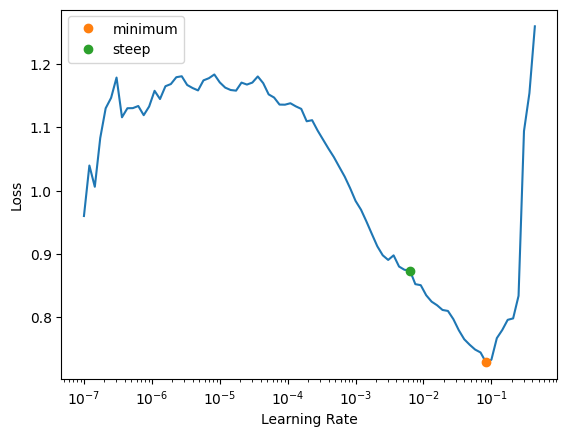

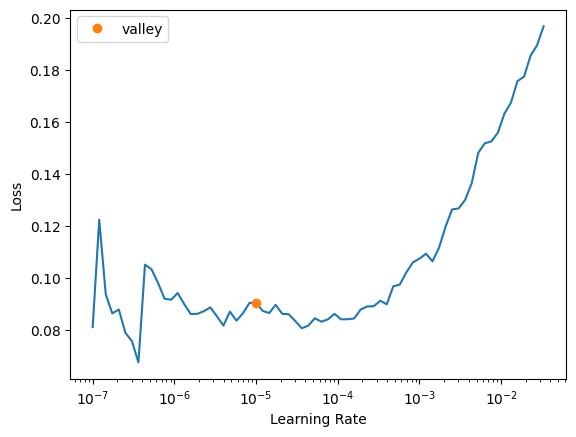

In [ ]:
learn = vision_learner(dls, densenet121, metrics=[accuracy, Precision(), Recall(), F1Score()]).to_fp16()
lr_min,lr_steep = learn.lr_find(suggest_funcs=(minimum, steep))
learn.fit_one_cycle(3, lr_steep)
learn.unfreeze()
lr_valley = learn.lr_find(suggest_funcs=(valley,)).valley
learn.fit_one_cycle(6, lr_max=slice(lr_valley/1000, lr_valley))

Based on these results, I'm going to reduce the number of frozen epochs to 2, as the third epoch actually performed worse, with the additional frozen training appearing to cause overfitting. Additionally, I changed the unfrozen learning rate slice from (lr_valley/100, lr_valley) to (lr_valley/1000, lr_valley) to address the validation loss increasing and decreasing, suggesting overfitting.

<div></div>

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.735129,0.500191,0.801115,0.989529,0.731613,0.841246,01:01
1,0.514542,0.600679,0.803903,0.991289,0.734194,0.843588,09:11


<div></div>

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.353260,0.570698,0.852230,0.990446,0.802581,0.886671,01:31
1,0.265951,0.334863,0.924721,0.991501,0.903226,0.945307,03:55
2,0.198996,0.240560,0.948885,0.989130,0.939355,0.963600,05:19
3,0.150510,0.237141,0.942379,0.987688,0.931613,0.958831,05:31
4,0.127376,0.224158,0.946097,0.989086,0.935484,0.961538,00:52
5,0.115570,0.207299,0.947026,0.989101,0.936774,0.962227,00:45


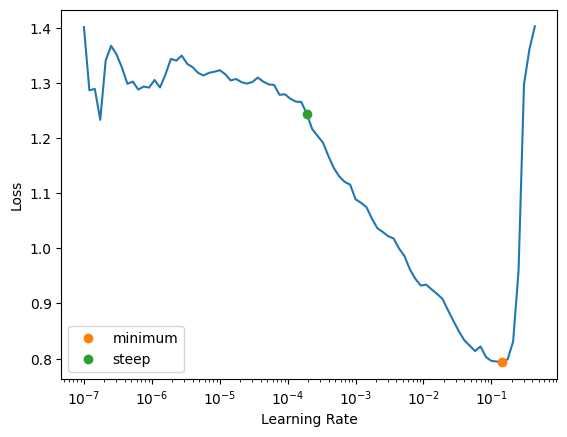

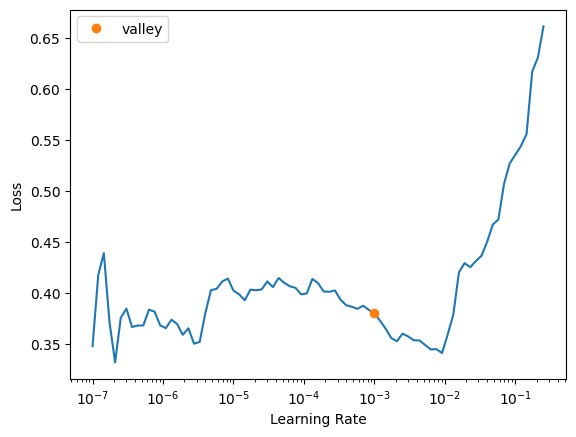

In [63]:
learn = vision_learner(dls, densenet121, metrics=[accuracy, Precision(), Recall(), F1Score()]).to_fp16()
lr_min,lr_steep = learn.lr_find(suggest_funcs=(minimum, steep))
learn.fit_one_cycle(2, lr_steep)
learn.unfreeze()
lr_valley = learn.lr_find(suggest_funcs=(valley,)).valley
learn.fit_one_cycle(6, lr_max=slice(lr_valley/1000, lr_valley))